In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as LinearRegression_SKL
from sklearn.metrics import mean_squared_error


## Loading Data

In [3]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
data = pd.DataFrame(housing.data)
data.columns = housing.feature_names
data['PRICE'] = housing.target
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
y = data[['PRICE']].to_numpy()
X_raw = data[housing.feature_names].to_numpy()
X_raw.shape, y.shape

((20640, 8), (20640, 1))

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

## Linear Regression

A linear regression model is written as:

$$Y = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_k x_k $$


The matrix form: $$\mathbf{y} = X\mathbf{w}$$

where $$\mathbf{y}=\begin{bmatrix}y_1\\y_2\\\vdots\\y_n\end{bmatrix},\;X=\begin{bmatrix}1&x_{11}&x_{12}&\cdots&x_{1k}\\1&x_{21}&x_{22}&\cdots&x_{2k}\\\vdots&\vdots&\vdots&\ddots&\vdots\\1&x_{n1}&x_{n2}&\cdots&x_{nk}\end{bmatrix},\;\mathbf{w}=\begin{bmatrix}w_0\\w_1\\\vdots\\w_k\end{bmatrix},\;\hat{\mathbf{y}}=X\mathbf{w}$$

The prediction is: $$\hat{\mathbf{y}} = X\mathbf{w}$$

In [7]:
# Adds a column of ones so the formula can solve for w0
X = np.c_[np.ones(len(X)), X]



The loss function measures how far our predictions are from the true values. We use the **Mean Squared Error (MSE)**:

$$L(\mathbf{w}) = \frac{1}{n}\|X\mathbf{w} - \mathbf{y}\|^2 = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$$

Expanding this:

$$L(\mathbf{w}) = \frac{1}{n}(X\mathbf{w} - \mathbf{y})^T (X\mathbf{w} - \mathbf{y})$$

**Step 1:** Let residual vector $\mathbf{e} = X\mathbf{w} - \mathbf{y}$

$$\Rightarrow L(\mathbf{w}) = \frac{1}{n}\mathbf{e}^T \mathbf{e}$$

Taking the gradient with respect to **w**:

$$\nabla_\mathbf{w} L = \frac{2}{n} X^T(X\mathbf{w} - \mathbf{y})$$

To minimize the loss, we set the gradient to zero. This gives the **closed-form solution**:

$$\mathbf{w} = (X^T X)^{-1} X^T \mathbf{y}$$

### MSE

In [8]:
def predict(X, w):
    return X @ w

In [9]:
def mse(y_pred, y):
    residuals = y_pred - y
    return (residuals.T @ residuals / len(y)).squeeze()

#### Closed Form

In [10]:
def closed_form(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

In [11]:
w_closed = closed_form(X, y)
y_pred = predict(X, w_closed)
mse_loss = mse(y_pred, y)

In [12]:
print(f"MSE (closed-form): {mse_loss:.10f}")

MSE (closed-form): 0.5243209862


#### Putting all together

In [13]:
class LinearRegression_Closed:
    def __init__(self):
        self.w = None
        
    def fit(self, X, y):
        self.w = np.linalg.inv(X.T @ X) @ X.T @ y
        return self

    def predict(self, X):
        return X @ self.w

In [14]:
lr_closed = LinearRegression_Closed().fit(X, y)
y_pred = lr_closed.predict(X)
loss_closed = mse(y_pred, y)

In [15]:
print(f"MSE (closed-form): {loss_closed:.10f}")

MSE (closed-form): 0.5243209862


### Gradient Descent

Gradient descent is an iterative method to find the weights $\mathbf{w}$ that minimize the MSE loss.

1. Start with an initial guess for weights (for example, zeros).
2. Compute predictions: $\hat{\mathbf{y}} = X\mathbf{w}$.
3. Compute the gradient of the loss:

$$\nabla_{\mathbf{w}} L = \frac{2}{n}X^T(X\mathbf{w} - \mathbf{y})$$

4. Update weights:

$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \nabla_{\mathbf{w}} L$$

5. Repeat steps 2 to 4 until reaching a satisfactory result.

Where:
- $\alpha$ is the learning rate (step size).
- One epoch means one full update using all training samples.
- Too large $\alpha$ may diverge; too small $\alpha$ may converge slowly.

In [16]:
def gradient_descent(X, y, learning_rate=0.1, epochs=1000):
    num_features = X.shape[1]
    w = np.zeros(shape=(num_features, 1))
    loss_history = []

    for _ in range(epochs):
        loss = mse(X@w, y)
        loss_history.append(loss)
        gradient = 2*(X.T @ (X@w - y)) / len(y)
        w -= learning_rate * gradient

    return w, loss_history

In [17]:
w_gd, loss_history = gradient_descent(X, y)

In [18]:
y_pred = predict(X, w_gd)
mse_loss_gd = mse(y_pred, y)
print(f"MSE (gradient descent): {mse_loss_gd:.10f}")
print(f"MSE (closed-form):      {loss_closed:.10f}")

MSE (gradient descent): 0.5243209863
MSE (closed-form):      0.5243209862


#### Putting all together

In [19]:
class LinearRegression_GD:
    def __init__(self, epochs=3000, learning_rate = 0.01):
        self.w = None
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.loss_history = []

    def fit(self, X, y):
        num_features = X.shape[1]
        self.w = np.zeros(shape=(num_features, 1))

        for _ in range(self.epochs):
            y_pred = self.predict(X)
            self.loss_history.append(mse(y_pred, y))
            gradient = 2*(X.T @ (X@self.w - y)) / len(y)
            self.w -= self.learning_rate * gradient

        return self

    def predict(self, X):
        return X @ self.w
    
    def get_loss_history(self):
        return self.loss_history


In [20]:
lr_gd = LinearRegression_GD()
w = lr_gd.fit(X, y)
y_pred = lr_gd.predict(X)
loss_gd = mse(y_pred, y)

print(f"From-scratch class MSE (closed-form):      {loss_closed:.10f}")
print(f"From-scratch class MSE (gradient descent): {loss_gd:.10f}")

From-scratch class MSE (closed-form):      0.5243209862
From-scratch class MSE (gradient descent): 0.5243780362


### Effect of Learning Rate

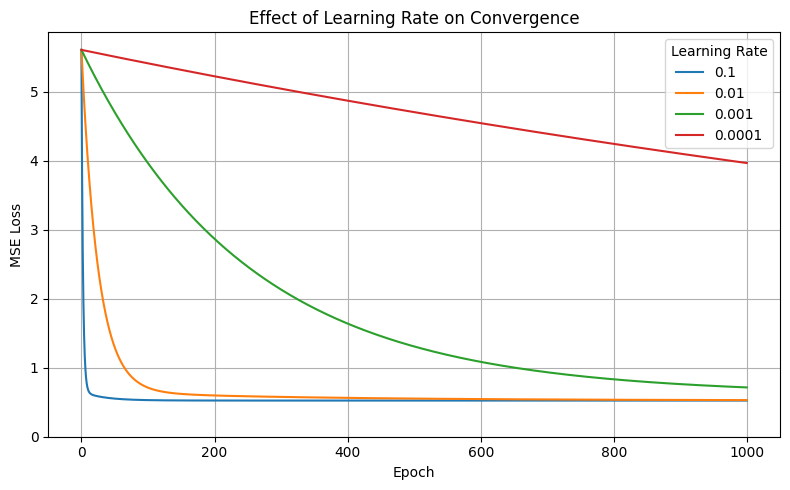

In [21]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]
epochs = 1000

plt.figure(figsize=(8, 5))

for lr in learning_rates:
    _, loss_history = gradient_descent(X, y, learning_rate=lr, epochs=epochs)
    plt.plot(loss_history, label=str(lr))

plt.title("Effect of Learning Rate on Convergence")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.ylim(bottom=0)
plt.legend(title="Learning Rate")
plt.grid(True)
plt.tight_layout()
plt.show()


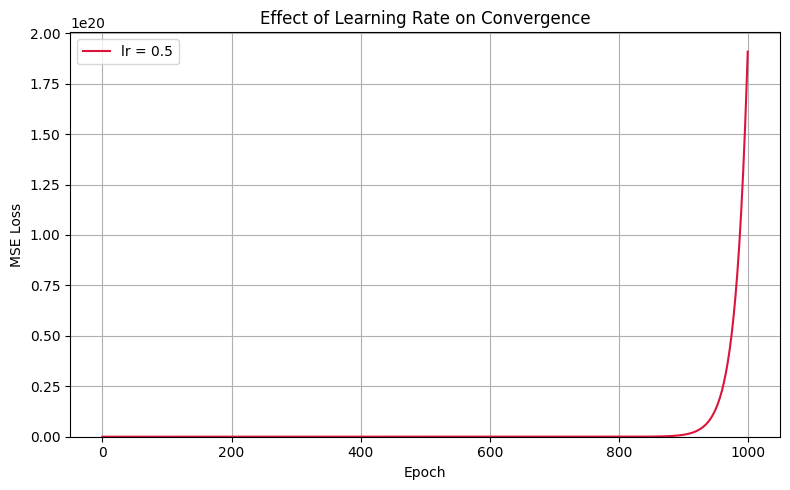

In [23]:
learning_rate = 0.5
epochs = 1000

_, loss_history = gradient_descent(X, y, learning_rate=learning_rate, epochs=epochs)

plt.figure(figsize=(8, 5))
plt.plot(loss_history, label=f"lr = {learning_rate}", color="crimson")
plt.title("Effect of Learning Rate on Convergence")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.ylim(bottom=0)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Compare with Sklearn

In [24]:
y = data[['PRICE']].to_numpy()
X = data[housing.feature_names].to_numpy()
X = np.c_[np.ones(len(X)), X]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train[:, 1:] = scaler.fit_transform(X_train[:, 1:])
X_test[:, 1:] = scaler.transform(X_test[:, 1:])



In [25]:

lr_closed = LinearRegression_Closed().fit(X_test, y_test)
lr_gd = LinearRegression_GD(epochs=3000, learning_rate=0.01).fit(X_train, y_train)

mse_closed_test = mse(lr_closed.predict(X_test), y_test)
mse_gd_test = mse(lr_gd.predict(X_test), y_test)
# sklearn baseline (X already has bias column, so disable extra intercept)
sk_model = LinearRegression_SKL(fit_intercept=False)
sk_model.fit(X_train, y_train.ravel())
y_pred_sk = sk_model.predict(X_test).reshape(-1, 1)
mse_sk_test = mean_squared_error(y_test, y_pred_sk)

print(f"Test MSE (closed-form): {mse_closed_test:.10f}")
print(f"Test MSE (gradient descent): {mse_gd_test:.10f}")
print(f"Test MSE (sklearn): {mse_sk_test:.10f}")

Test MSE (closed-form): 0.5293336128
Test MSE (gradient descent): 0.5562552006
Test MSE (sklearn): 0.5558915987


## Polynomial Regression from Scratch

Polynomial regression extends linear regression by creating features that are powers of the original features.

For a single input feature $x$, polynomial regression of degree $d$ creates features:
$$\mathbf{x}_{poly} = [1, x, x^2, x^3, \ldots, x^d]$$

Then we apply linear regression to these polynomial features. The model becomes:
$$\hat{y} = w_0 + w_1 x + w_2 x^2 + \cdots + w_d x^d$$

In [26]:
def polynomial_features(X, degree):
    n_samples, n_features = X.shape
    
    # Start with the bias term (column of ones)
    X_poly = np.ones((n_samples, 1))
    # For each degree from 1 to degree
    for d in range(1, degree + 1):
        # For each feature
        for i in range(n_features):
            # Create the feature raised to power d
            feature_power = X[:, i:i+1] ** d
            X_poly = np.append(X_poly, feature_power, axis=1)
    
    return X_poly

In [27]:
class PolynomialRegression:
    def __init__(self, degree=2):
        self.degree = degree
        self.model = None

    def fit(self, X, y):
        X_poly = polynomial_features(X, self.degree)
        self.model = LinearRegression_SKL(fit_intercept=False)
        self.model.fit(X_poly, y)
        return self

    def predict(self, X):
        X_poly = polynomial_features(X, self.degree)
        return self.model.predict(X_poly)

#### Generating data

In [28]:
def true_fun(X):
    return 4 * X**3 - 3 * X**2 + 0.5 * X + 1
np.random.seed(0)
n_samples = 30
x = np.sort(np.random.rand(n_samples))
y = true_fun(x) + np.random.randn(n_samples) * 0.1
X_test = np.linspace(0, 1, 30)
X_test_col = X_test.reshape(-1, 1)

#### Underfitting

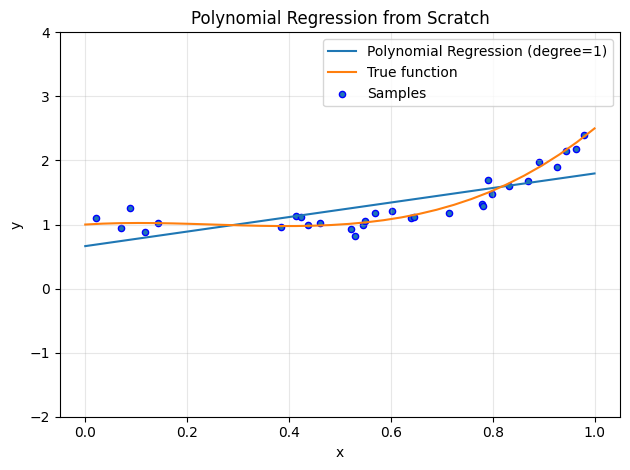

In [29]:
poly_reg = PolynomialRegression(degree=1)
poly_reg.fit(x.reshape(-1, 1), y)
y_pred_poly = poly_reg.predict(X_test_col)

plt.plot(X_test, y_pred_poly, label="Polynomial Regression (degree=1)")
plt.plot(X_test, true_fun(X_test), label="True function")
plt.scatter(x, y, edgecolor="b", s=20, label="Samples")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(bottom=-2, top=4)
plt.legend(loc="best")
plt.title("Polynomial Regression from Scratch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Good Fit

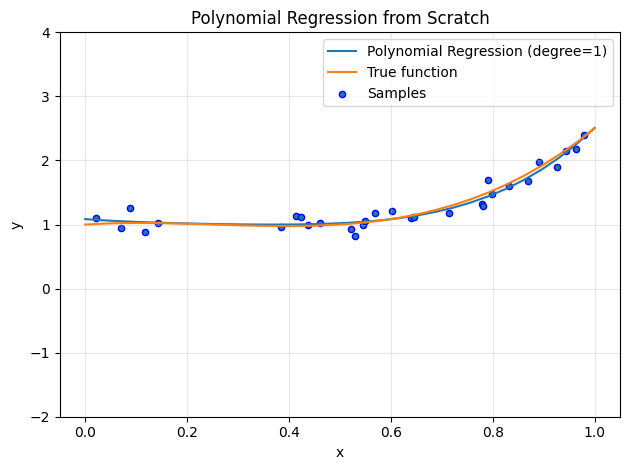

In [30]:
poly_reg = PolynomialRegression(degree=4)
poly_reg.fit(x.reshape(-1, 1), y)
y_pred_poly = poly_reg.predict(X_test_col)

plt.plot(X_test, y_pred_poly, label="Polynomial Regression (degree=1)")
plt.plot(X_test, true_fun(X_test), label="True function")
plt.scatter(x, y, edgecolor="b", s=20, label="Samples")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(bottom=-2, top=4)
plt.legend(loc="best")
plt.title("Polynomial Regression from Scratch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Overfitting

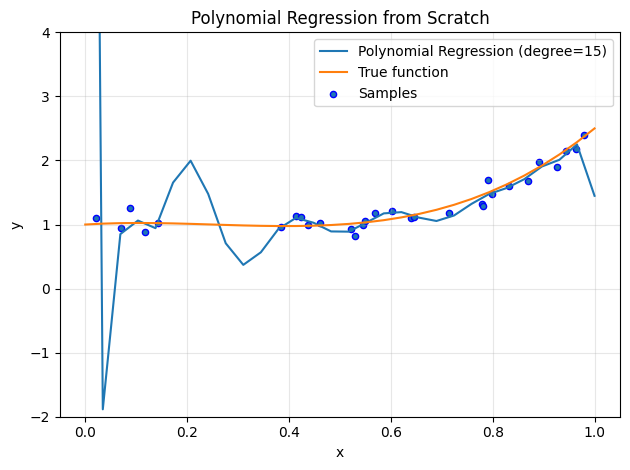

In [31]:
poly_reg = PolynomialRegression(degree=15)
poly_reg.fit(x.reshape(-1, 1), y)
y_pred_poly = poly_reg.predict(X_test_col)

plt.plot(X_test, y_pred_poly, label="Polynomial Regression (degree=15)")
plt.plot(X_test, true_fun(X_test), label="True function")
plt.scatter(x, y, edgecolor="b", s=20, label="Samples")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(bottom=-2, top=4)
plt.legend(loc="best")
plt.title("Polynomial Regression from Scratch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()